<a href="https://colab.research.google.com/github/giankev/lightweight-model-for-signal-processing/blob/ofdm-case/non_linear_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install sionna tensorflow

  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-pyth

In [3]:
# COMPLETE NOTEBOOK SCRIPT
# OFDM + 16-QAM + 5G LDPC + CFO/Phase + AWGN + PA Nonlinearity
# Baseline classica PA-aware con stima della non linearità
# Training + evaluation del ricevitore neurale ibrido
# ===============================================================

from __future__ import annotations

from dataclasses import dataclass, fields
from typing import Dict, Any, Optional
import copy
import os
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import sionna
from sionna.phy.mapping import Constellation, Mapper, Demapper
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.ofdm.modulator import OFDMModulator
from sionna.phy.ofdm.demodulator import OFDMDemodulator

# ---------------------------------------------------------------
# Sionna global RNG seed (if available)
# ---------------------------------------------------------------
try:
    from sionna.phy import config as sn_config
except Exception:
    sn_config = None

# ---------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------
SEED = 46
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ===============================================================
# Configuration
# ===============================================================
@dataclass(frozen=True)
class SimConfig:
    # Dataset
    num_examples: int = 10_000

    # Modulation / coding
    seq_length: int = 128                  # must equal n_data_sym * fft_size
    bits_per_symbol: int = 4               # 16-QAM
    k: int = 256

    # Eb/N0
    ebn0_db_min: float = 0.0
    ebn0_db_max: float = 12.0

    # Impairments
    phase_min: float = -np.pi
    phase_max: float = np.pi
    cfo_mode: str = "direct"               # "direct" or "epsilon"
    cfo_norm_min: float = -2e-4            # cycles/sample
    cfo_norm_max: float = +2e-4
    cfo_eps_min: float = -0.05
    cfo_eps_max: float = +0.05

    # OFDM
    waveform: str = "ofdm"
    ofdm_fft_size: int = 64
    ofdm_cp_len: int = 16
    ofdm_num_pilot_symbols: int = 1
    ofdm_num_data_symbols: int = 2
    ofdm_l_min: int = 0

    # Pilots
    pilot_seed: int = 999
    pilot_bits_per_symbol: int = 2         # QPSK pilots

    # Receiver blocks
    demap_method: str = "app"
    dec_num_iter: int = 15
    cn_update: str = "minsum"

    # Reproducibility
    seed: int = 46
    seed_noise: Optional[int] = None
    llr_noise_scaling: float = 1.0

    # Overhead accounting
    include_pilot_overhead_in_no: bool = True
    include_cp_overhead_in_no: bool = True

    # PA nonlinearity (Rapp memoryless model)
    use_pa_nonlinearity: bool = True
    pa_ibo_db: float = 3.0                 # input backoff
    pa_smoothness: float = 2.0             # Rapp p
    baseline_use_pa_inverse: bool = True
    baseline_estimate_pa: bool = True
    pa_inverse_clip: float = 0.985
    baseline_pa_ibo_search_min_db: float = 0.0
    baseline_pa_ibo_search_max_db: float = 8.0
    baseline_pa_ibo_grid_size: int = 81

    # Format / dtypes
    channels_last: bool = True
    tf_rdtype: tf.dtypes.DType = tf.float32
    tf_cdtype: tf.dtypes.DType = tf.complex64


def cfg_clone(cfg: SimConfig, **updates) -> SimConfig:
    valid = {f.name for f in fields(SimConfig)}
    base = {k: v for k, v in vars(cfg).items() if k in valid}
    base.update(updates)
    return SimConfig(**base)


# ===============================================================
# Helpers
# ===============================================================
def set_global_seed(seed: int, seed_sionna: Optional[int] = None) -> None:
    np.random.seed(int(seed))
    tf.random.set_seed(int(seed))
    if sn_config is not None and seed_sionna is not None:
        sn_config.seed = int(seed_sionna)


def complex_to_2ch_real(x: tf.Tensor, channels_last: bool = True) -> tf.Tensor:
    i = tf.math.real(x)
    q = tf.math.imag(x)
    return tf.stack([i, q], axis=-1 if channels_last else -2)


def expj(theta: tf.Tensor, cdtype: tf.DType) -> tf.Tensor:
    return tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)


def awgn_manual_with_seed(x: tf.Tensor,
                          no: tf.Tensor,
                          seed: int,
                          rdtype: tf.DType,
                          cdtype: tf.DType) -> tf.Tensor:
    rng = tf.random.Generator.from_seed(int(seed))
    std = tf.sqrt(no / tf.constant(2.0, rdtype))
    nr = rng.normal(tf.shape(x), dtype=rdtype) * std
    ni = rng.normal(tf.shape(x), dtype=rdtype) * std
    w = tf.complex(nr, ni)
    return tf.cast(x, cdtype) + tf.cast(w, cdtype)


def build_sionna_blocks(cfg: SimConfig):
    m = int(cfg.bits_per_symbol)
    constellation = Constellation("qam", num_bits_per_symbol=m)
    mapper = Mapper(constellation=constellation)
    demapper = Demapper(cfg.demap_method, constellation=constellation)

    n = int(cfg.seq_length) * m
    encoder = LDPC5GEncoder(k=int(cfg.k), n=int(n), num_bits_per_symbol=m)
    decoder = LDPC5GDecoder(
        encoder=encoder,
        num_iter=int(cfg.dec_num_iter),
        return_infobits=True,
        hard_out=True,
        cn_update=str(cfg.cn_update),
    )
    return constellation, mapper, demapper, encoder, decoder


def make_deterministic_symbols_tf(cfg: SimConfig,
                                  N: int,
                                  num_symbols: int,
                                  bits_per_symbol: int,
                                  seed: int) -> Dict[str, tf.Tensor]:
    rng = tf.random.Generator.from_seed(int(seed))
    bits = rng.uniform(
        [num_symbols * bits_per_symbol],
        minval=0,
        maxval=2,
        dtype=tf.int32
    )

    const = Constellation("qam", num_bits_per_symbol=int(bits_per_symbol))
    mapper = Mapper(constellation=const)

    x1 = tf.cast(mapper(tf.reshape(bits, [1, num_symbols * bits_per_symbol])), cfg.tf_cdtype)
    x = tf.tile(x1, [N, 1])
    return {"bits": bits, "x": x}


# ===============================================================
# Rapp PA nonlinearity
# ===============================================================
def rapp_amam_tf(r_in: tf.Tensor, a_sat: tf.Tensor, p: float, rdtype: tf.DType) -> tf.Tensor:
    eps = tf.constant(1e-9, rdtype)
    return r_in / tf.pow(1.0 + tf.pow(r_in / (a_sat + eps), 2.0 * p), 1.0 / (2.0 * p))


def rapp_pa_tf(x: tf.Tensor,
               ibo_db: float,
               p: float,
               rdtype: tf.DType,
               cdtype: tf.DType):
    """
    Memoryless Rapp PA:
        y = x / (1 + (|x|/A_sat)^(2p))^(1/(2p))

    A_sat is derived from the average input power and the desired IBO.
    """
    p_avg = tf.reduce_mean(tf.abs(x) ** 2)  # scalar over the whole generated batch
    ibo_lin = tf.pow(tf.constant(10.0, rdtype), tf.constant(float(ibo_db), rdtype) / 10.0)
    a_sat = tf.sqrt(p_avg * ibo_lin)

    r_in = tf.abs(x)
    r_out = rapp_amam_tf(r_in, a_sat, p, rdtype)
    scale = r_out / tf.maximum(r_in, tf.constant(1e-9, rdtype))
    y = tf.cast(scale, cdtype) * tf.cast(x, cdtype)
    return y, tf.cast(a_sat, rdtype)


def inverse_rapp_pa_tf(y: tf.Tensor,
                       a_sat: tf.Tensor,
                       p: float,
                       clip_frac: float,
                       rdtype: tf.DType,
                       cdtype: tf.DType):
    """
    Inverse of the Rapp model using amplitude-only inversion:
        r_out = r_in / (1 + (r_in/A_sat)^(2p))^(1/(2p))
        r_in  = r_out / (1 - (r_out/A_sat)^(2p))^(1/(2p))

    To avoid blow-up close to saturation, clip r_out < clip_frac * A_sat.
    """
    eps = tf.constant(1e-9, rdtype)
    r_out = tf.abs(y)

    a_sat = tf.cast(a_sat, rdtype)
    r_clip = tf.cast(clip_frac, rdtype) * a_sat
    r_use = tf.minimum(r_out, r_clip)

    inside = 1.0 - tf.pow(r_use / (a_sat + eps), 2.0 * p)
    inside = tf.maximum(inside, tf.constant(1e-6, rdtype))

    r_in_hat = r_use / tf.pow(inside, 1.0 / (2.0 * p))
    scale = r_in_hat / tf.maximum(r_use, eps)
    return tf.cast(scale, cdtype) * tf.cast(y, cdtype)


def estimate_pa_asat_grid_tf(y_pilot_corr: tf.Tensor,
                             x_pilot_lin: tf.Tensor,
                             ibo_min_db: float,
                             ibo_max_db: float,
                             grid_size: int,
                             p: float,
                             rdtype: tf.DType):
    """
    Estimate A_sat from the derotated received pilot and the known linear pilot waveform.

    Search in IBO space:
      A_sat = sqrt(E|x_pilot_lin|^2 * IBO_lin)

    Minimize amplitude MSE between observed pilot envelope and Rapp-compressed envelope.
    """
    eps = tf.constant(1e-9, rdtype)

    r_out_obs = tf.abs(y_pilot_corr)                  # [N,P]
    r_in_known = tf.abs(x_pilot_lin)                  # [N,P]
    p_in_avg = tf.reduce_mean(r_in_known ** 2, axis=1, keepdims=True)  # [N,1]

    ibo_grid_db = tf.linspace(
        tf.constant(float(ibo_min_db), rdtype),
        tf.constant(float(ibo_max_db), rdtype),
        int(grid_size)
    )  # [G]
    ibo_grid_lin = tf.pow(tf.constant(10.0, rdtype), ibo_grid_db / 10.0)  # [G]

    # Candidate A_sat per batch item and grid point: [N,G]
    a_sat_grid = tf.sqrt(p_in_avg * ibo_grid_lin[None, :])

    # Predicted output amplitude under each candidate: [N,G,P]
    r_in_e = r_in_known[:, None, :]                       # [N,1,P]
    a_sat_e = a_sat_grid[:, :, None]                      # [N,G,1]
    r_pred = r_in_e / tf.pow(
        1.0 + tf.pow(r_in_e / (a_sat_e + eps), 2.0 * p),
        1.0 / (2.0 * p)
    )

    mse = tf.reduce_mean((r_pred - r_out_obs[:, None, :]) ** 2, axis=-1)  # [N,G]
    idx = tf.argmin(mse, axis=1, output_type=tf.int32)                     # [N]
    a_sat_hat = tf.gather(a_sat_grid, idx, axis=1, batch_dims=1)[:, None] # [N,1]
    return a_sat_hat


# ===============================================================
# OFDM TX + Channel (with PA nonlinearity)
# ===============================================================
def simulate_full_frames_tf(cfg: SimConfig) -> Dict[str, Any]:
    assert cfg.waveform.lower() == "ofdm", "This notebook version is OFDM-only."

    set_global_seed(cfg.seed)
    rng = tf.random.Generator.from_seed(int(cfg.seed))

    N = int(cfg.num_examples)
    m = int(cfg.bits_per_symbol)
    k = int(cfg.k)

    fft_size = int(cfg.ofdm_fft_size)
    cp_len = int(cfg.ofdm_cp_len)
    n_pilot_sym = int(cfg.ofdm_num_pilot_symbols)
    n_data_sym = int(cfg.ofdm_num_data_symbols)
    n_total_sym = n_pilot_sym + n_data_sym

    L = int(cfg.seq_length)
    if L != n_data_sym * fft_size:
        raise ValueError(
            f"OFDM requires seq_length = ofdm_num_data_symbols*ofdm_fft_size "
            f"({n_data_sym}*{fft_size}={n_data_sym*fft_size}), got {L}."
        )

    n = L * m
    if not (0 < k < n):
        raise ValueError(f"Invalid k={k}. Must satisfy 0 < k < n={n}.")
    R = float(k) / float(n)

    _, mapper_data, _, encoder, _ = build_sionna_blocks(cfg)

    # ---------------------------
    # Data symbols
    # ---------------------------
    info_bits = rng.uniform([N, k], minval=0, maxval=2, dtype=tf.int32)
    coded_bits_f = encoder(tf.cast(info_bits, cfg.tf_rdtype))
    coded_bits = tf.cast(coded_bits_f, tf.int32)

    x_data_flat = tf.cast(mapper_data(coded_bits), cfg.tf_cdtype)               # [N,L]
    x_data_grid = tf.reshape(x_data_flat, [N, n_data_sym, fft_size])            # [N,Nd,F]

    # ---------------------------
    # Deterministic pilot symbols (frequency domain)
    # ---------------------------
    pilot_bps = int(cfg.pilot_bits_per_symbol)
    pilot_pack = make_deterministic_symbols_tf(
        cfg,
        N=N,
        num_symbols=n_pilot_sym * fft_size,
        bits_per_symbol=pilot_bps,
        seed=int(cfg.pilot_seed),
    )
    pilot_bits = pilot_pack["bits"]
    x_pilot_grid = tf.reshape(pilot_pack["x"], [N, n_pilot_sym, fft_size])

    # Full OFDM resource grid
    x_grid = tf.concat([x_pilot_grid, x_data_grid], axis=1)

    # OFDM modulation
    mod = OFDMModulator(cyclic_prefix_length=cp_len)
    x_time_lin = tf.cast(mod(x_grid), cfg.tf_cdtype)

    # Linear pilot waveform reference
    P_time = n_pilot_sym * (fft_size + cp_len)
    x_pilot_lin_time = x_time_lin[:, :P_time]

    # ---------------------------
    # PA nonlinearity
    # ---------------------------
    if cfg.use_pa_nonlinearity:
        x_time_nl, pa_a_sat_scalar = rapp_pa_tf(
            x_time_lin,
            ibo_db=float(cfg.pa_ibo_db),
            p=float(cfg.pa_smoothness),
            rdtype=cfg.tf_rdtype,
            cdtype=cfg.tf_cdtype,
        )
    else:
        x_time_nl = x_time_lin
        pa_a_sat_scalar = tf.constant(1.0, cfg.tf_rdtype)

    # Pilot waveform after PA (actual transmitted pilot)
    x_pilot_nl_time = x_time_nl[:, :P_time]

    # ---------------------------
    # Phase + CFO
    # ---------------------------
    T_time = int(n_total_sym * (fft_size + cp_len))
    phi0 = rng.uniform([N, 1], minval=cfg.phase_min, maxval=cfg.phase_max, dtype=cfg.tf_rdtype)

    if str(cfg.cfo_mode).lower() == "epsilon":
        eps = rng.uniform([N, 1], minval=cfg.cfo_eps_min, maxval=cfg.cfo_eps_max, dtype=cfg.tf_rdtype)
        cfo = eps / tf.constant(float(fft_size), dtype=cfg.tf_rdtype)  # cycles/sample
        cfo_eps = eps
        cfo_unit = "cycles/sample (from epsilon)"
    else:
        cfo = rng.uniform([N, 1], minval=cfg.cfo_norm_min, maxval=cfg.cfo_norm_max, dtype=cfg.tf_rdtype)
        cfo_eps = cfo * tf.constant(float(fft_size), dtype=cfg.tf_rdtype)
        cfo_unit = "cycles/sample"

    t = tf.range(T_time, dtype=cfg.tf_rdtype)[None, :]
    phi_total = phi0 + tf.constant(2.0 * np.pi, cfg.tf_rdtype) * cfo * t
    x_tx_phase = x_time_nl * expj(phi_total, cfg.tf_cdtype)

    # ---------------------------
    # Noise variance
    # ---------------------------
    ebn0_db = rng.uniform([N], minval=cfg.ebn0_db_min, maxval=cfg.ebn0_db_max, dtype=cfg.tf_rdtype)
    ebn0_lin = tf.pow(tf.constant(10.0, cfg.tf_rdtype), ebn0_db / 10.0)

    overhead_val = 1.0
    if cfg.include_pilot_overhead_in_no:
        overhead_val *= (n_total_sym / float(n_data_sym))
    if cfg.include_cp_overhead_in_no:
        overhead_val *= ((fft_size + cp_len) / float(fft_size))
    overhead = tf.constant(overhead_val, dtype=cfg.tf_rdtype)

    es = tf.reduce_mean(tf.abs(x_tx_phase) ** 2, axis=1, keepdims=True)
    no = es / (tf.reshape(ebn0_lin, [-1, 1]) * (m * R)) * overhead

    noise_seed = cfg.seed if cfg.seed_noise is None else int(cfg.seed_noise)
    y_rx = awgn_manual_with_seed(
        x_tx_phase,
        no,
        seed=noise_seed,
        rdtype=cfg.tf_rdtype,
        cdtype=cfg.tf_cdtype,
    )

    pa_a_sat = tf.ones([N, 1], dtype=cfg.tf_rdtype) * pa_a_sat_scalar

    return {
        "info_bits": info_bits,
        "coded_bits": coded_bits,
        "pilot_bits": pilot_bits,
        "x_pilot_lin": x_pilot_lin_time,   # linear pilot waveform
        "x_pilot": x_pilot_nl_time,        # actual pilot waveform after PA
        "x_data": x_data_flat,             # clean data in freq domain
        "x_grid": x_grid,                  # clean full grid in freq domain
        "x_tx_lin": x_time_lin,            # linear OFDM waveform
        "x_tx": x_time_nl,                 # actual transmitted waveform after PA
        "y_rx": y_rx,                      # received waveform
        "phi0": phi0,
        "cfo_norm": cfo,
        "cfo_eps": cfo_eps,
        "ebn0_db": ebn0_db,
        "no": no,
        "pa_a_sat": pa_a_sat,
        "meta": {
            "waveform": "ofdm",
            "N": N,
            "m": m,
            "k": k,
            "n": int(n),
            "R": float(R),
            "L": int(L),
            "P": int(P_time),
            "T": int(T_time),
            "fft_size": fft_size,
            "cp_len": cp_len,
            "num_pilot_ofdm_symbols": n_pilot_sym,
            "num_data_ofdm_symbols": n_data_sym,
            "num_total_ofdm_symbols": n_total_sym,
            "ofdm_l_min": int(cfg.ofdm_l_min),
            "seed": int(cfg.seed),
            "seed_noise": int(noise_seed),
            "pilot_seed": int(cfg.pilot_seed),
            "pilot_bits_per_symbol": int(cfg.pilot_bits_per_symbol),
            "include_pilot_overhead_in_no": bool(cfg.include_pilot_overhead_in_no),
            "include_cp_overhead_in_no": bool(cfg.include_cp_overhead_in_no),
            "cfo_mode": str(cfg.cfo_mode),
            "cfo_unit": cfo_unit,
            "use_pa_nonlinearity": bool(cfg.use_pa_nonlinearity),
            "pa_ibo_db": float(cfg.pa_ibo_db),
            "pa_smoothness": float(cfg.pa_smoothness),
            "channel": "OFDM; Rapp PA + phase + CFO + AWGN",
            "sionna_version": getattr(sionna, "__version__", "unknown"),
        }
    }


# ===============================================================
# Offline dataset
# ===============================================================
def generate_dataset_offline(cfg: SimConfig) -> Dict[str, Any]:
    full = simulate_full_frames_tf(cfg)

    P_time = int(full["meta"]["P"])
    T_time = int(full["meta"]["T"])
    fft_size = int(full["meta"]["fft_size"])
    cp_len = int(full["meta"]["cp_len"])
    n_pilot_sym = int(full["meta"]["num_pilot_ofdm_symbols"])
    n_data_sym = int(full["meta"]["num_data_ofdm_symbols"])
    D_time = n_data_sym * (fft_size + cp_len)

    tx_iq_full = complex_to_2ch_real(full["x_tx"], cfg.channels_last).numpy().astype(np.float32)
    rx_iq_full = complex_to_2ch_real(full["y_rx"], cfg.channels_last).numpy().astype(np.float32)

    if cfg.channels_last:
        tx_iq_pilot_time = tx_iq_full[:, :P_time, :]
        rx_iq_pilot_time = rx_iq_full[:, :P_time, :]
        tx_iq_data_time = tx_iq_full[:, P_time:P_time + D_time, :]
        rx_iq_data_time = rx_iq_full[:, P_time:P_time + D_time, :]
    else:
        tx_iq_pilot_time = tx_iq_full[:, :, :P_time]
        rx_iq_pilot_time = rx_iq_full[:, :, :P_time]
        tx_iq_data_time = tx_iq_full[:, :, P_time:P_time + D_time]
        rx_iq_data_time = rx_iq_full[:, :, P_time:P_time + D_time]

    ds: Dict[str, Any] = {
        "info_bits": full["info_bits"].numpy().astype(np.uint8),
        "coded_bits": full["coded_bits"].numpy().astype(np.uint8),
        "pilot_bits": full["pilot_bits"].numpy().astype(np.uint8),

        "tx_iq_full_time": tx_iq_full,
        "rx_iq_full_time": rx_iq_full,
        "tx_iq_pilot_time": tx_iq_pilot_time,
        "rx_iq_pilot_time": rx_iq_pilot_time,
        "tx_iq_data_time": tx_iq_data_time,
        "rx_iq_data_time": rx_iq_data_time,

        "phi0": full["phi0"].numpy().astype(np.float32),
        "cfo_norm": full["cfo_norm"].numpy().astype(np.float32),
        "ebn0_db": full["ebn0_db"].numpy().astype(np.float32),
        "no": full["no"].numpy().astype(np.float32),
        "pa_a_sat": full["pa_a_sat"].numpy().astype(np.float32),

        "meta": full["meta"],
    }

    demod = OFDMDemodulator(
        fft_size=fft_size,
        l_min=int(full["meta"].get("ofdm_l_min", 0)),
        cyclic_prefix_length=cp_len,
    )
    y_grid_raw = demod(full["y_rx"])

    ds["rx_grid_raw"] = complex_to_2ch_real(y_grid_raw, channels_last=True).numpy().astype(np.float32)
    ds["tx_grid"] = complex_to_2ch_real(full["x_grid"], channels_last=True).numpy().astype(np.float32)
    ds["cfo_eps"] = full["cfo_eps"].numpy().astype(np.float32)

    return ds


# ===============================================================
# Classical baseline PA-aware
# ===============================================================
def estimate_phi_cfo_ml_grid(cfg: SimConfig,
                             y_pilot: tf.Tensor,
                             x_pilot_lin: tf.Tensor,
                             cfo_min: float,
                             cfo_max: float,
                             grid_size: int = 129):
    """
    Phase/CFO estimation using the *linear* pilot waveform as reference.
    The normalization removes AM/AM mismatch, so the estimator stays robust
    even when PA compression is present.
    """
    rdtype = cfg.tf_rdtype
    cdtype = cfg.tf_cdtype

    P = tf.shape(y_pilot)[1]
    two_pi = tf.constant(2.0 * np.pi, dtype=rdtype)
    eps_f = tf.constant(1e-9, dtype=rdtype)

    x_pow = tf.abs(x_pilot_lin) ** 2
    r = y_pilot * tf.math.conj(x_pilot_lin)
    r = r / tf.cast(x_pow + eps_f, cdtype)

    f_grid = tf.linspace(tf.constant(float(cfo_min), rdtype),
                         tf.constant(float(cfo_max), rdtype),
                         int(grid_size))

    p = tf.cast(tf.range(P)[None, :], rdtype)
    f = tf.reshape(f_grid, [-1, 1])
    theta = -two_pi * f * p

    E = tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)
    z = tf.einsum("np,mp->nm", r, E)

    mags = tf.abs(z)
    idx = tf.argmax(mags, axis=1, output_type=tf.int32)

    cfo_hat = tf.gather(f_grid, idx)[:, None]
    z_best = tf.gather(z, idx, axis=1, batch_dims=1)
    z_best = z_best[:, None]
    phi_hat = tf.cast(tf.math.angle(z_best), rdtype)

    denom = tf.reduce_sum(tf.abs(r), axis=1, keepdims=True) + eps_f
    conf = tf.abs(z_best) / denom
    return phi_hat, cfo_hat, conf


def classical_receiver_with_phi_cfo(cfg: SimConfig,
                                    full: Dict[str, Any],
                                    phi_hat: tf.Tensor,
                                    cfo_hat: tf.Tensor) -> Dict[str, Any]:
    _, _, demapper, _, decoder = build_sionna_blocks(cfg)

    meta = full["meta"]
    no = tf.cast(full["no"], cfg.tf_rdtype)
    y_rx = full["y_rx"]

    coded_bits = tf.cast(full["coded_bits"], tf.uint8)
    info_bits = tf.cast(full["info_bits"], tf.uint8)

    fft_size = int(meta["fft_size"])
    cp_len = int(meta["cp_len"])
    n_pilot_sym = int(meta["num_pilot_ofdm_symbols"])
    l_min = int(meta.get("ofdm_l_min", 0))
    T = int(meta["T"])

    # ---------------------------
    # Derotation
    # ---------------------------
    two_pi = tf.constant(2.0 * np.pi, dtype=cfg.tf_rdtype)
    t = tf.cast(tf.range(T)[None, :], cfg.tf_rdtype)
    phi_total_hat = phi_hat + two_pi * cfo_hat * t
    y_corr = y_rx * expj(-phi_total_hat, cfg.tf_cdtype)

    # ---------------------------
    # Estimate PA nonlinearity from the pilot, then inverse it
    # ---------------------------
    if cfg.use_pa_nonlinearity and cfg.baseline_use_pa_inverse:
        P_time = int(meta["P"])
        y_pilot_corr = y_corr[:, :P_time]
        x_pilot_lin = full["x_pilot_lin"]

        if cfg.baseline_estimate_pa:
            a_sat_hat = estimate_pa_asat_grid_tf(
                y_pilot_corr=y_pilot_corr,
                x_pilot_lin=x_pilot_lin,
                ibo_min_db=float(cfg.baseline_pa_ibo_search_min_db),
                ibo_max_db=float(cfg.baseline_pa_ibo_search_max_db),
                grid_size=int(cfg.baseline_pa_ibo_grid_size),
                p=float(cfg.pa_smoothness),
                rdtype=cfg.tf_rdtype,
            )
        else:
            a_sat_hat = tf.cast(full["pa_a_sat"], cfg.tf_rdtype)

        y_corr = inverse_rapp_pa_tf(
            y_corr,
            a_sat=a_sat_hat,
            p=float(cfg.pa_smoothness),
            clip_frac=float(cfg.pa_inverse_clip),
            rdtype=cfg.tf_rdtype,
            cdtype=cfg.tf_cdtype,
        )

    # ---------------------------
    # OFDM demodulation
    # ---------------------------
    demod = OFDMDemodulator(
        fft_size=fft_size,
        l_min=l_min,
        cyclic_prefix_length=cp_len,
    )
    y_grid = demod(y_corr)
    y_data_grid = y_grid[:, n_pilot_sym:, :]
    y_data_symbols = tf.reshape(y_data_grid, [tf.shape(y_data_grid)[0], -1])

    alpha = tf.constant(float(getattr(cfg, "llr_noise_scaling", 1.0)), dtype=cfg.tf_rdtype)
    no_eff = no * alpha

    llr = tf.cast(demapper(y_data_symbols, no_eff), cfg.tf_rdtype)
    hard_coded = tf.cast(llr > 0.0, tf.uint8)

    info_hat_f = decoder(llr)
    info_hat = tf.cast(info_hat_f > 0.5, tf.uint8)

    ber_pre = tf.reduce_mean(tf.cast(hard_coded != coded_bits, cfg.tf_rdtype))
    ber_post = tf.reduce_mean(tf.cast(info_hat != info_bits, cfg.tf_rdtype))
    bler_post = tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_bits, axis=1), cfg.tf_rdtype))

    return {
        "phi_hat": phi_hat,
        "cfo_hat": cfo_hat,
        "llr": llr,
        "info_bits_hat": info_hat,
        "metrics": {
            "ber_pre_coded": float(ber_pre.numpy()),
            "ber_post_info": float(ber_post.numpy()),
            "bler_post_info": float(bler_post.numpy()),
        }
    }


def classical_receiver(cfg: SimConfig, full: Dict[str, Any]) -> Dict[str, Any]:
    meta = full["meta"]
    P = int(meta["P"])
    fft_size = int(meta["fft_size"])

    y_rx = full["y_rx"]
    x_pilot_lin = full["x_pilot_lin"]
    y_pilot = y_rx[:, :P]

    if str(cfg.cfo_mode).lower() == "epsilon":
        cfo_min = float(cfg.cfo_eps_min) / float(fft_size)
        cfo_max = float(cfg.cfo_eps_max) / float(fft_size)
    else:
        cfo_min = float(cfg.cfo_norm_min)
        cfo_max = float(cfg.cfo_norm_max)

    if P >= 2:
        phi_hat, cfo_hat, conf = estimate_phi_cfo_ml_grid(
            cfg, y_pilot, x_pilot_lin,
            cfo_min=cfo_min,
            cfo_max=cfo_max,
            grid_size=129
        )
    else:
        z = tf.reduce_sum(y_pilot * tf.math.conj(x_pilot_lin), axis=1, keepdims=True)
        phi_hat = tf.cast(tf.math.angle(z), cfg.tf_rdtype)
        cfo_hat = tf.zeros_like(phi_hat)
        conf = tf.ones_like(phi_hat)

    out = classical_receiver_with_phi_cfo(cfg, full, phi_hat, cfo_hat)
    out["conf"] = conf
    return out


# ===============================================================
# Dataset loaders for PyTorch
# ===============================================================
def get_pytorch_ofdm_loaders(base_cfg, batch_size=128):
    print("Generating OFDM dataset (nonlinear channel): 60% 4-8 dB, 20% 0-4 dB, 20% 8-12 dB...")

    cfg_mid  = cfg_clone(base_cfg, num_examples=6000, ebn0_db_min=4.0, ebn0_db_max=8.0)
    cfg_low  = cfg_clone(base_cfg, num_examples=2000, ebn0_db_min=0.0, ebn0_db_max=4.0)
    cfg_high = cfg_clone(base_cfg, num_examples=2000, ebn0_db_min=8.0, ebn0_db_max=12.0)

    ds_mid  = generate_dataset_offline(cfg_mid)
    ds_low  = generate_dataset_offline(cfg_low)
    ds_high = generate_dataset_offline(cfg_high)

    x_rx = np.concatenate([ds_mid["rx_iq_data_time"], ds_low["rx_iq_data_time"], ds_high["rx_iq_data_time"]], axis=0)
    x_pilot = np.concatenate([ds_mid["rx_iq_pilot_time"], ds_low["rx_iq_pilot_time"], ds_high["rx_iq_pilot_time"]], axis=0)
    target_bits = np.concatenate([ds_mid["coded_bits"], ds_low["coded_bits"], ds_high["coded_bits"]], axis=0)

    tx_grid_mid  = ds_mid["tx_grid"]
    tx_grid_low  = ds_low["tx_grid"]
    tx_grid_high = ds_high["tx_grid"]
    n_pilot_sym = base_cfg.ofdm_num_pilot_symbols

    x_data_mid  = tx_grid_mid[:,  n_pilot_sym:, :, :].reshape(tx_grid_mid.shape[0],  -1, 2)
    x_data_low  = tx_grid_low[:,  n_pilot_sym:, :, :].reshape(tx_grid_low.shape[0],  -1, 2)
    x_data_high = tx_grid_high[:, n_pilot_sym:, :, :].reshape(tx_grid_high.shape[0], -1, 2)
    x_data = np.concatenate([x_data_mid, x_data_low, x_data_high], axis=0)

    phi0 = np.concatenate([ds_mid["phi0"], ds_low["phi0"], ds_high["phi0"]], axis=0)
    cfo  = np.concatenate([ds_mid["cfo_norm"], ds_low["cfo_norm"], ds_high["cfo_norm"]], axis=0)
    ebn0 = np.concatenate([ds_mid["ebn0_db"], ds_low["ebn0_db"], ds_high["ebn0_db"]], axis=0)
    no   = np.concatenate([ds_mid["no"], ds_low["no"], ds_high["no"]], axis=0).squeeze(-1)

    x_rx_t = torch.tensor(x_rx, dtype=torch.float32).permute(0, 2, 1)
    x_pilot_t = torch.tensor(x_pilot, dtype=torch.float32).permute(0, 2, 1)
    target_bits_t = torch.tensor(target_bits, dtype=torch.float32).reshape(-1, base_cfg.seq_length, 4).permute(0, 2, 1)
    target_iq_t = torch.tensor(x_data, dtype=torch.float32).permute(0, 2, 1)

    phi0_t = torch.tensor(phi0, dtype=torch.float32).squeeze(-1)
    cfo_t = torch.tensor(cfo, dtype=torch.float32).squeeze(-1)
    ebn0_t = torch.tensor(ebn0, dtype=torch.float32)
    no_t = torch.tensor(no, dtype=torch.float32)

    dataset = TensorDataset(
        x_rx_t, x_pilot_t, phi0_t, cfo_t, ebn0_t, no_t, target_bits_t, target_iq_t
    )

    g = torch.Generator().manual_seed(SEED)
    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size], generator=g)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=0)
    return train_loader, val_loader

# ===============================================================
# Neural receiver
# ===============================================================
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        assert dim % heads == 0, "dim must be divisible by heads"
        self.heads = heads
        self.dim_head = dim // heads
        self.scale = self.dim_head ** -0.5

        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.to_out = nn.Linear(dim, dim)

        self.gamma = nn.Linear(dim, dim)
        self.beta = nn.Linear(dim, dim)

    def forward(self, x, latent_z):
        # x: [B, N, D]
        # latent_z: [B, D]
        style_scale = self.gamma(latent_z).unsqueeze(1)   # [B,1,D]
        style_shift = self.beta(latent_z).unsqueeze(1)    # [B,1,D]
        x = x * (1.0 + style_scale) + style_shift

        b, n, d = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = [
            t.view(b, n, self.heads, self.dim_head).transpose(1, 2)
            for t in qkv
        ]  # each: [B, H, N, Dh]

        q = q.softmax(dim=-1) * self.scale
        k = k.softmax(dim=-2)

        context = torch.matmul(k.transpose(-1, -2), v)   # [B, H, Dh, Dh]
        out = torch.matmul(q, context)                   # [B, H, N, Dh]
        out = out.transpose(1, 2).reshape(b, n, d)

        return self.to_out(out)


class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        return self.relu(x + out)


class HybridNeuralReceiverOFDM(nn.Module):
    """
    Versione compatibile con il resto del notebook:
    - include ResidualBlock1D e LinearAttention
    - accetta cfo_max nel costruttore
    - accetta no nel forward (anche se qui non viene usato)
    - usa CFO in cycles/sample, quindi nella compensazione compare 2*pi*cfo*t
    - mantiene l'architettura che hai chiesto
    """
    def __init__(
        self,
        seq_len=160,
        n_pilots=80,
        ofdm_fft_size=64,
        ofdm_cp_len=16,
        cfo_max=2e-4,
    ):
        super().__init__()
        self.fft_size = int(ofdm_fft_size)
        self.cp_len = int(ofdm_cp_len)
        self.cfo_max = max(float(cfo_max), 1e-8)

        in_dim = (2 * seq_len) + (2 * n_pilots)
        self.input_norm = nn.BatchNorm1d(in_dim)

        # Impairment estimator
        self.estimator = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 2),
        )

        # Mantengo la tua idea: conditioning con 2 ingressi
        self.latent_proj = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Tanh(),
        )

        # Backbone frequency-domain
        self.feat_extract = nn.Conv1d(2, 64, kernel_size=7, padding=3)
        self.res1 = ResidualBlock1D(64)
        self.attn = LinearAttention(dim=64, heads=4)
        self.norm_attn = nn.LayerNorm(64)
        self.res2 = ResidualBlock1D(64)

        # Heads
        self.iq_head = nn.Conv1d(64, 2, kernel_size=1)
        self.demap_mlp = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(16, 4, kernel_size=1),
        )

    def forward(
        self,
        x,
        pilots,
        no=None,          # tenuto per compatibilità col notebook
        gt_phi=None,
        gt_cfo=None,
        mix_ratio=0.0,
    ):
        # x:      [B, 2, L_time]
        # pilots: [B, 2, P_time]

        x = x.float()
        pilots = pilots.float()

        if gt_phi is not None:
            gt_phi = gt_phi.float()
        if gt_cfo is not None:
            gt_cfo = gt_cfo.float()

        # ----------------------------------------------------------
        # 1) Joint impairment estimation from data + pilots
        # ----------------------------------------------------------
        x_flat = x.reshape(x.size(0), -1)
        p_flat = pilots.reshape(pilots.size(0), -1)
        est_feats = self.input_norm(torch.cat([x_flat, p_flat], dim=1))

        est_params = self.estimator(est_feats)
        est_phi = est_params[:, 0]

        # CFO limitato nel range del dataset
        est_cfo = torch.tanh(est_params[:, 1]) * self.cfo_max  # cycles/sample

        # Teacher forcing / curriculum
        if (gt_phi is not None) and (gt_cfo is not None) and (mix_ratio < 1.0):
            phi = (1.0 - mix_ratio) * gt_phi + mix_ratio * est_phi
            cfo = (1.0 - mix_ratio) * gt_cfo + mix_ratio * est_cfo
        else:
            phi, cfo = est_phi, est_cfo

        # ----------------------------------------------------------
        # 2) Latent conditioning
        # ----------------------------------------------------------
        z_input = torch.stack(
            [
                torch.cos(phi),
                cfo / self.cfo_max,
            ],
            dim=1
        )  # [B,2]

        z = self.latent_proj(z_input)  # [B,64]

        # ----------------------------------------------------------
        # 3) Explicit impairment compensation in time domain
        # ----------------------------------------------------------
        B, _, L = x.shape
        t = torch.arange(L, device=x.device, dtype=x.dtype).unsqueeze(0)
        two_pi = x.new_tensor(2.0 * np.pi)

        # CFO è in cycles/sample -> serve 2*pi
        phase_ramp = phi.unsqueeze(1) + two_pi * cfo.unsqueeze(1) * t
        cos_t = torch.cos(-phase_ramp)
        sin_t = torch.sin(-phase_ramp)

        r_I = x[:, 0, :] * cos_t - x[:, 1, :] * sin_t
        r_Q = x[:, 0, :] * sin_t + x[:, 1, :] * cos_t

        x_comp = torch.complex(r_I, r_Q)  # [B, L]

        # ----------------------------------------------------------
        # 4) OFDM processing: reshape -> CP removal -> FFT -> shift
        # ----------------------------------------------------------
        sym_len = self.fft_size + self.cp_len
        if L % sym_len != 0:
            raise ValueError(
                f"Input length {L} is not divisible by OFDM symbol length {sym_len}."
            )

        n_sym = L // sym_len
        x_sym = x_comp.reshape(B, n_sym, sym_len)

        x_no_cp = x_sym[:, :, self.cp_len:]
        x_freq = torch.fft.fft(x_no_cp, norm="ortho", dim=-1)
        x_freq = torch.fft.fftshift(x_freq, dim=-1)

        x_freq_flat = x_freq.reshape(B, n_sym * self.fft_size)
        feat_in = torch.stack([x_freq_flat.real, x_freq_flat.imag], dim=1)  # [B,2,N]

        # ----------------------------------------------------------
        # 5) Feature extraction + linear attention
        # ----------------------------------------------------------
        feat = F.relu(self.feat_extract(feat_in))  # [B,64,N]
        feat = self.res1(feat)

        feat_attn = feat.permute(0, 2, 1)  # [B,N,64]
        feat_attn = self.attn(self.norm_attn(feat_attn), z)
        feat = feat + feat_attn.permute(0, 2, 1)

        feat = self.res2(feat)

        # ----------------------------------------------------------
        # 6) Outputs
        # ----------------------------------------------------------
        est_iq = self.iq_head(feat)    # [B,2,N]
        logits = self.demap_mlp(feat)  # [B,4,N]

        return logits, est_phi, est_cfo, est_iq


# ===============================================================
# Utils
# ===============================================================
def count_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params


def fit_llr_temperature(model, val_loader, device):
    model.eval()
    logits_all, bits_all = [], []

    with torch.no_grad():
        for x, p, y_p, y_c, ebn0, no, target_bits, target_iq in val_loader:
            x = x.to(device, non_blocking=True)
            p = p.to(device, non_blocking=True)
            no = no.to(device, non_blocking=True)
            target_bits = target_bits.to(device, non_blocking=True)

            bit_logits, _, _, _ = model(x, p, no=no, mix_ratio=1.0)
            logits_all.append(bit_logits.permute(0, 2, 1).reshape(-1))
            bits_all.append(target_bits.permute(0, 2, 1).reshape(-1))

    logits = torch.cat(logits_all)
    bits = torch.cat(bits_all)

    alpha = torch.nn.Parameter(torch.tensor(1.0, device=device))
    opt = torch.optim.LBFGS([alpha], lr=0.25, max_iter=50, line_search_fn="strong_wolfe")
    loss_fn = nn.BCEWithLogitsLoss()

    def closure():
        opt.zero_grad()
        a = alpha.clamp(0.05, 20.0)
        loss = loss_fn(logits * a, bits)
        loss.backward()
        return loss

    opt.step(closure)
    return float(alpha.clamp(0.05, 20.0).item())


# ===============================================================
# Training configuration
# ===============================================================
cfg_ofdm = SimConfig(
    num_examples=10000,
    bits_per_symbol=4,
    k=256,
    demap_method="app",
    dec_num_iter=15,
    cn_update="minsum",
    seed=46,
    channels_last=True,
    cfo_mode="direct",
    cfo_norm_min=-2e-4,
    cfo_norm_max=+2e-4,
    ebn0_db_min=0.0,
    ebn0_db_max=12.0,
    include_pilot_overhead_in_no=True,
    include_cp_overhead_in_no=True,
    waveform="ofdm",
    ofdm_fft_size=64,
    ofdm_cp_len=16,
    ofdm_num_data_symbols=2,
    ofdm_num_pilot_symbols=1,
    use_pa_nonlinearity=True,
    pa_ibo_db=3.0,
    pa_smoothness=2.0,
    baseline_use_pa_inverse=True,
    baseline_estimate_pa=True,
    pa_inverse_clip=0.985,
    baseline_pa_ibo_search_min_db=0.0,
    baseline_pa_ibo_search_max_db=8.0,
    baseline_pa_ibo_grid_size=81,
)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

EPOCHS = 55
BATCH_SIZE = 128

train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=BATCH_SIZE)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time,
    n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size,
    ofdm_cp_len=cfg_ofdm.ofdm_cp_len,
    cfo_max=cfg_ofdm.cfo_norm_max,
).to(DEVICE)

total_params, trainable_params = count_params(model_ofdm)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Model size ~ {total_params * 4 / (1024**2):.2f} MB")

optimizer = torch.optim.AdamW(model_ofdm.parameters(), lr=1.5e-3, weight_decay=8e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

best_state = None
best_val_ber = float("inf")

# ===============================================================
# Training loop
# ===============================================================
for epoch in range(EPOCHS):
    model_ofdm.train()
    train_loss = 0.0
    train_ber = 0.0

    warm_epochs = int(0.70 * EPOCHS)
    mix = min(1.0, epoch / max(1, warm_epochs))
    aux_w = max(0.10, 0.50 * (1.0 - epoch / EPOCHS))

    for x, p, y_p, y_c, ebn0, no, target_bits, target_iq in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        p = p.to(DEVICE, non_blocking=True)
        y_p = y_p.to(DEVICE, non_blocking=True)
        y_c = y_c.to(DEVICE, non_blocking=True)
        no = no.to(DEVICE, non_blocking=True)
        target_bits = target_bits.to(DEVICE, non_blocking=True)
        target_iq = target_iq.to(DEVICE, non_blocking=True)

        smooth_target_bits = target_bits * 0.99 + 0.005
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(
                x, p, no=no, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix
            )

            loss_bits = criterion_bce(bit_logits, smooth_target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo / cfg_ofdm.cfo_norm_max, y_c / cfg_ofdm.cfo_norm_max)
            loss_iq = criterion_mse(est_iq, target_iq)

            loss = loss_bits + aux_w * (
                0.25 * loss_phi +
                0.25 * loss_cfo +
                0.50 * loss_iq
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            train_ber += (pred_bits != target_bits).float().mean().item()

    scheduler.step()

    model_ofdm.eval()
    val_loss = 0.0
    val_ber = 0.0

    with torch.no_grad():
        for x, p, y_p, y_c, ebn0, no, target_bits, target_iq in val_loader:
            x = x.to(DEVICE, non_blocking=True)
            p = p.to(DEVICE, non_blocking=True)
            y_p = y_p.to(DEVICE, non_blocking=True)
            y_c = y_c.to(DEVICE, non_blocking=True)
            no = no.to(DEVICE, non_blocking=True)
            target_bits = target_bits.to(DEVICE, non_blocking=True)
            target_iq = target_iq.to(DEVICE, non_blocking=True)

            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(
                x, p, no=no, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0
            )

            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo / cfg_ofdm.cfo_norm_max, y_c / cfg_ofdm.cfo_norm_max)
            loss_iq = criterion_mse(est_iq, target_iq)

            loss = loss_bits + aux_w * (
                0.25 * loss_phi +
                0.25 * loss_cfo +
                0.50 * loss_iq
            )

            val_loss += loss.item()
            pred_bits = (bit_logits > 0).float()
            val_ber += (pred_bits != target_bits).float().mean().item()

    train_loss /= len(train_loader)
    train_ber /= len(train_loader)
    val_loss /= len(val_loader)
    val_ber /= len(val_loader)

    if val_ber < best_val_ber:
        best_val_ber = val_ber
        best_state = copy.deepcopy(model_ofdm.state_dict())

    print(
        f"Ep {epoch+1:02d}/{EPOCHS} | "
        f"mix={mix:.2f} aux_w={aux_w:.3f} | "
        f"Train Loss: {train_loss:.4f} (BER: {train_ber*100:.2f}%) | "
        f"Val Loss: {val_loss:.4f} (BER: {val_ber*100:.2f}%)"
    )

if best_state is not None:
    model_ofdm.load_state_dict(best_state)

llr_temp = fit_llr_temperature(model_ofdm, val_loader, DEVICE)
print(f"Calibrated LLR temperature = {llr_temp:.4f}")

# ===============================================================
# Optional complexity report
# ===============================================================
try:
    os.system("pip install thop -q")
    from thop import profile

    dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
    dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
    dummy_no = torch.full((1,), 1e-3).to(DEVICE)

    macs, params = profile(
        model_ofdm,
        inputs=(dummy_x, dummy_p, dummy_no),
        verbose=False,
    )
    print("\n" + "=" * 90)
    print("MODEL COMPLEXITY")
    print("=" * 90)
    print(f"Params: {params:,}")
    print(f"MACs:   {macs/1e6:.2f} M")
    print(f"FLOPs:  {2*macs/1e6:.2f} MFLOPs")
except Exception as e:
    print(f"THOP profiling skipped: {e}")

# ===============================================================
# Pre-FEC evaluation
# ===============================================================
ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating PA-aware Classical Baseline vs Hybrid Neural Receiver (OFDM) ---")
model_ofdm.eval()

with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = cfg_clone(
            cfg_ofdm,
            num_examples=2000,
            ebn0_db_min=float(ebno),
            ebn0_db_max=float(ebno),
        )

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"], dtype=torch.float32).permute(0, 2, 1).to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"], dtype=torch.float32).permute(0, 2, 1).to(DEVICE)
        no_t = torch.tensor(ds_eval["no"], dtype=torch.float32).squeeze(-1).to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"], dtype=torch.float32).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, no=no_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# ===============================================================
# Post-FEC evaluation
# ===============================================================
ebn0_range_post = range(0, 13, 1)
base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "=" * 90)
print("POST-FEC BER & BLER EVALUATION (NONLINEAR CHANNEL)")
print("=" * 90)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = cfg_clone(
            cfg_ofdm,
            num_examples=2000,
            ebn0_db_min=float(ebno),
            ebn0_db_max=float(ebno),
        )

        # Baseline
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # ML model
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"], dtype=torch.float32).permute(0, 2, 1).to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"], dtype=torch.float32).permute(0, 2, 1).to(DEVICE)
        no_t = torch.tensor(ds_eval["no"], dtype=torch.float32).squeeze(-1).to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, no=no_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        llr_tf = tf.convert_to_tensor(llr_ml_np * llr_temp, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        print(
            f"Eb/N0={ebno:4.1f} dB | "
            f"BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
            f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}"
        )

# ===============================================================
# Final report
# ===============================================================
print("\n" + "=" * 110)
print("FINAL PERFORMANCE REPORT")
print("=" * 110)

print(f"\n{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 110)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0

    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(
        f"{ebno:<11.1f} | "
        f"{b_ber:<13.3e} | "
        f"{m_ber:<13.3e} | "
        f"{imp_ber_str:<12} | "
        f"{b_bler:<13.3e} | "
        f"{m_bler:<13.3e} | "
        f"{imp_bler_str:<12}"
    )

Using device: cuda
Generating OFDM dataset (nonlinear channel): 60% 4-8 dB, 20% 0-4 dB, 20% 8-12 dB...
Total params: 152,088
Trainable params: 152,088
Model size ~ 0.58 MB
Ep 01/55 | mix=0.00 aux_w=0.500 | Train Loss: 0.7545 (BER: 27.78%) | Val Loss: 0.6327 (BER: 21.03%)
Ep 02/55 | mix=0.03 aux_w=0.491 | Train Loss: 0.4684 (BER: 15.38%) | Val Loss: 0.5663 (BER: 20.11%)
Ep 03/55 | mix=0.05 aux_w=0.482 | Train Loss: 0.4394 (BER: 15.24%) | Val Loss: 0.5566 (BER: 19.94%)
Ep 04/55 | mix=0.08 aux_w=0.473 | Train Loss: 0.4287 (BER: 15.22%) | Val Loss: 0.5262 (BER: 18.89%)
Ep 05/55 | mix=0.11 aux_w=0.464 | Train Loss: 0.4114 (BER: 15.20%) | Val Loss: 0.5041 (BER: 18.24%)
Ep 06/55 | mix=0.13 aux_w=0.455 | Train Loss: 0.4081 (BER: 15.24%) | Val Loss: 0.5111 (BER: 18.28%)
Ep 07/55 | mix=0.16 aux_w=0.445 | Train Loss: 0.4017 (BER: 15.21%) | Val Loss: 0.5164 (BER: 18.72%)
Ep 08/55 | mix=0.18 aux_w=0.436 | Train Loss: 0.3960 (BER: 15.22%) | Val Loss: 0.5137 (BER: 18.68%)
Ep 09/55 | mix=0.21 aux_w=0.

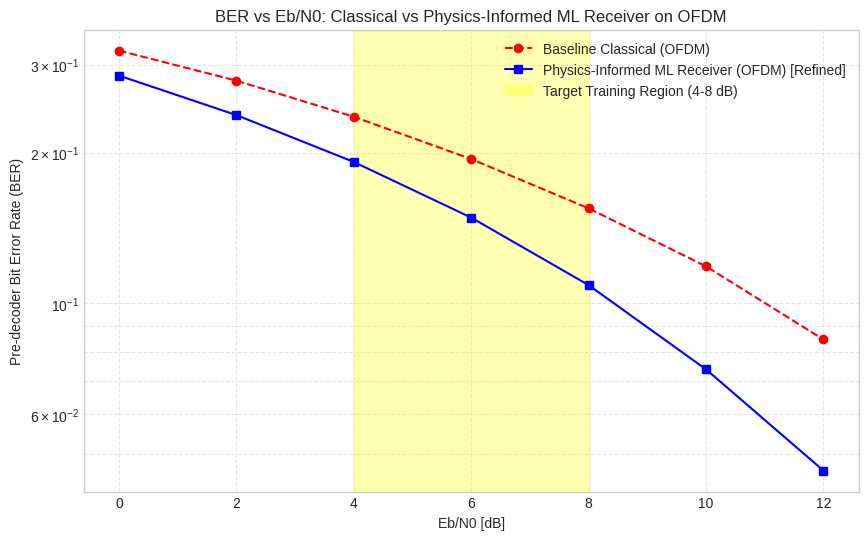

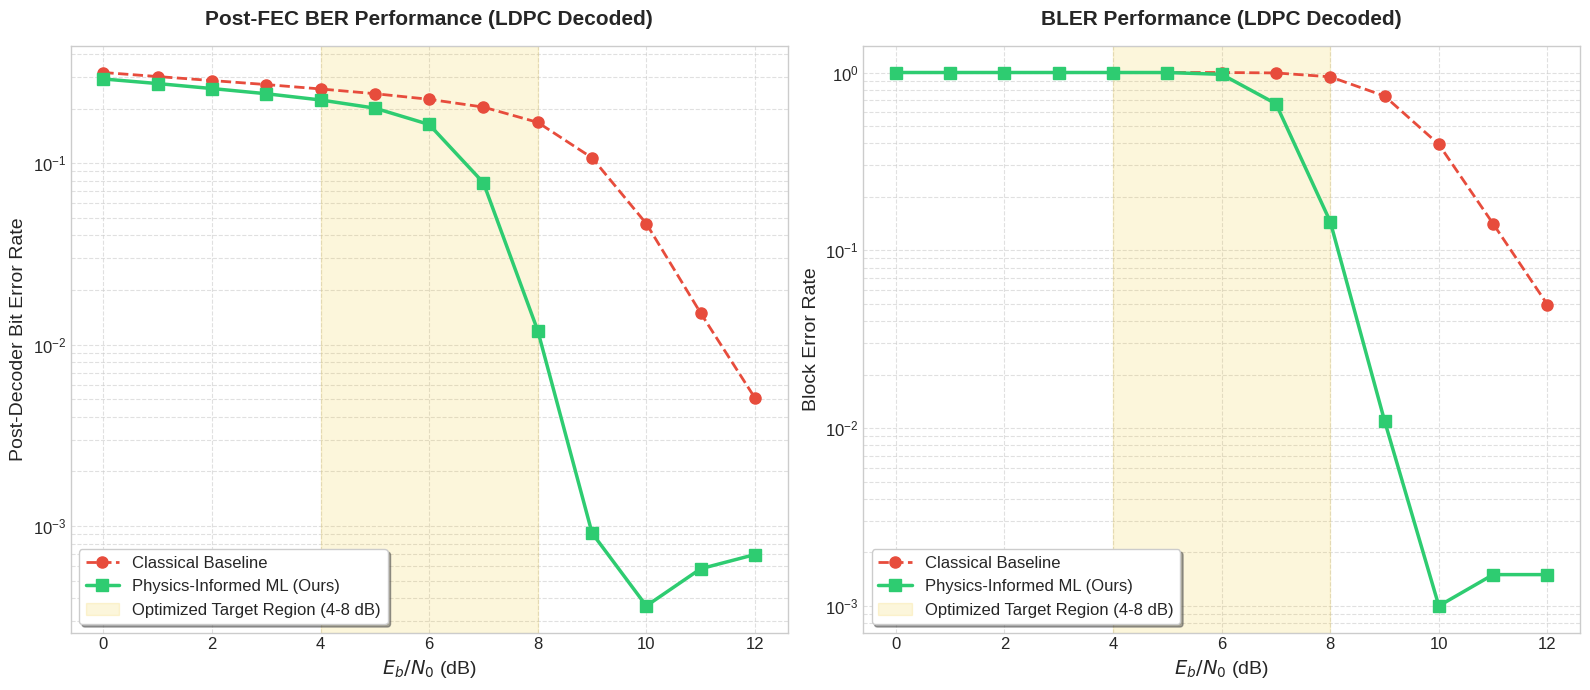

In [5]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()